# 07 - Optional Forecasting (Experimental)

**This section is experimental and not guaranteed.** It demonstrates a simple, explainable next-day session-count forecast using a Random Forest regressor on calendar features. It is a proof-of-concept, not a production forecasting system -- with only one year of synthetic data, the model cannot learn genuine multi-year seasonality, and results should not be over-interpreted.

In [1]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('../data/processed/ev_charging_features.csv')
df['date'] = pd.to_datetime(df['date'])
daily = df.groupby('date').size().reset_index(name='sessions').sort_values('date')
daily['dow'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['day_of_year'] = daily['date'].dt.dayofyear
daily['is_weekend'] = daily['dow'].isin([5,6]).astype(int)
# lag features -- previous day's and previous week's session count (no future leakage)
daily['lag_1'] = daily['sessions'].shift(1)
daily['lag_7'] = daily['sessions'].shift(7)
daily = daily.dropna().reset_index(drop=True)
daily.head()

,date,sessions,dow,month,day_of_year,is_weekend,lag_1,lag_7
0,2024-01-08,201,0,1,8,0,157.0,228.0
1,2024-01-09,244,1,1,9,0,201.0,230.0
2,2024-01-10,200,2,1,10,0,244.0,250.0
3,2024-01-11,206,3,1,11,0,200.0,217.0
4,2024-01-12,236,4,1,12,0,206.0,203.0


## Train/test split (chronological, not random -- avoids leakage)

In [2]:
features = ['dow','month','day_of_year','is_weekend','lag_1','lag_7']
split_point = int(len(daily) * 0.8)
train, test = daily.iloc[:split_point], daily.iloc[split_point:]
X_train, y_train = train[features], train['sessions']
X_test, y_test = test[features], test['sessions']
print(f'Train: {len(train)} days, Test: {len(test)} days')

Train: 287 days, Test: 72 days


In [3]:
model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f'MAE: {mae:.1f} sessions/day')
print(f'R^2: {r2:.3f}')

MAE: 31.4 sessions/day
R^2: 0.044


## Actual vs predicted (test period)

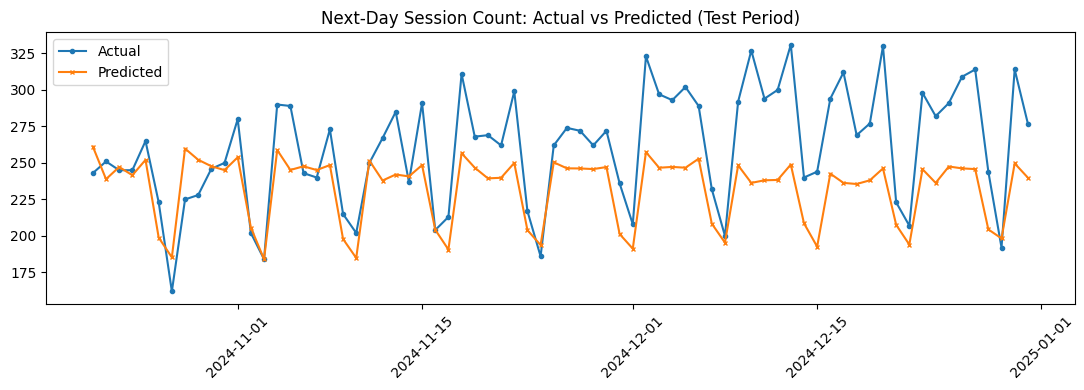

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(11,4))
plt.plot(test['date'], y_test.values, label='Actual', marker='o', markersize=3)
plt.plot(test['date'], preds, label='Predicted', marker='x', markersize=3)
plt.legend(); plt.title('Next-Day Session Count: Actual vs Predicted (Test Period)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## Feature importance

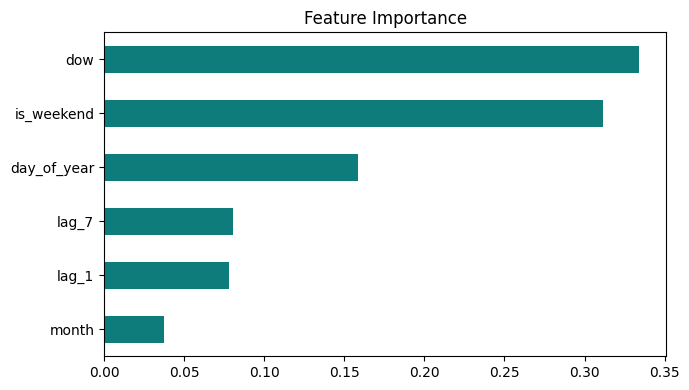

In [5]:
imp = pd.Series(model.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', figsize=(7,4), color='#0E7C7B', title='Feature Importance')
plt.tight_layout(); plt.show()

### Caveats
- Trained on ~1 year of **synthetic** data; the model has not seen multiple real yearly cycles.
- `lag_1`/`lag_7` are legitimate (past-only) features, but a live system would need a monitoring process to detect drift as real usage patterns evolve.
- This notebook is a demonstration of a sound, leakage-free forecasting *approach*, not a production-ready demand forecast.